/tmp/ipykernel_3242/4228707313.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"{X[i]} → {a2[i][0]:.3f} → {int(a2[i]>0.5)}")


[0 0] → 0.015 → 0
[0 1] → 0.984 → 1
[1 0] → 0.983 → 1
[1 1] → 0.021 → 0


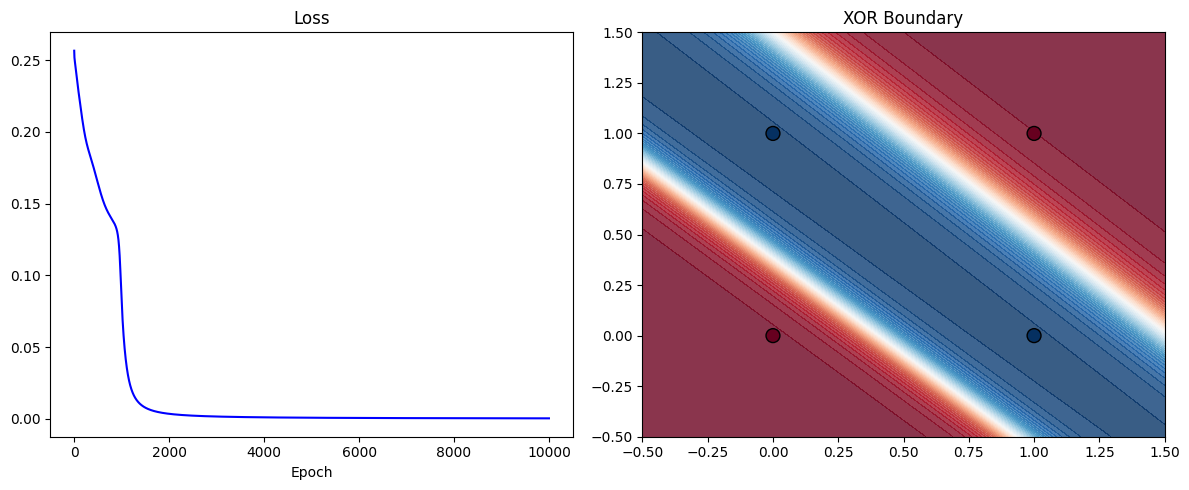

In [2]:
import numpy as np, matplotlib.pyplot as plt

# ── Data ──────────────────────────────────────────────
X = np.array([[0,0],[0,1],[1,0],[1,1]]); y = np.array([[0],[1],[1],[0]])

# ── Sigmoid ────────────────────────────────────────────
sig = lambda x, d=False: x*(1-x) if d else 1/(1+np.exp(-x))

# ── Weights ────────────────────────────────────────────
np.random.seed(1)
W1, b1 = np.random.randn(2,2), np.zeros((1,2))
W2, b2 = np.random.randn(2,1), np.zeros((1,1))
losses = []

# ── Train ──────────────────────────────────────────────
for _ in range(10000):
    a1 = sig(X@W1 + b1); a2 = sig(a1@W2 + b2)  # Forward
    e  = y - a2; losses.append(np.mean(e**2))     # Loss
    d2 = e*sig(a2,True); d1 = d2@W2.T*sig(a1,True) # Backprop
    W2+=a1.T@d2*.5; b2+=d2.sum(0)*.5             # Update
    W1+=X.T@d1*.5;  b1+=d1.sum(0)*.5

# ── Results ────────────────────────────────────────────
for i in range(4):
    print(f"{X[i]} → {a2[i][0]:.3f} → {int(a2[i]>0.5)}")

# ── Plots ──────────────────────────────────────────────
plt.figure(figsize=(12,5))

plt.subplot(1,2,1); plt.plot(losses, 'b')
plt.title('Loss'); plt.xlabel('Epoch')

xx,yy = np.meshgrid(np.linspace(-.5,1.5,100), np.linspace(-.5,1.5,100))
g   = np.c_[xx.ravel(), yy.ravel()]
out = sig(sig(g@W1+b1)@W2+b2).reshape(xx.shape)

plt.subplot(1,2,2)
plt.contourf(xx, yy, out, 50, cmap='RdBu', alpha=.8)
plt.scatter(X[:,0], X[:,1], c=y.ravel(), cmap='RdBu', edgecolors='k', s=100)
plt.title('XOR Boundary'); plt.tight_layout(); plt.show()